In [1]:
import pandas as pd
import polars as pl
import seaborn as sns
import numpy as np
import geopandas
from datacommons_client.client import DataCommonsClient

In [2]:
client = DataCommonsClient(dc_instance="datacommons.one.org")

In [3]:
pd.set_option('display.max_rows', 10)

Notes:

- We will likely have underrepresentation of WDBs that are in areas with smaller populations since the WIOA data does not report the WBD code when their are less than 50 participants.


In [4]:
dict_workforce_boards = {}
dict_workforce_boards[2023] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2023.xlsx", skiprows=8)
dict_workforce_boards[2022] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2022.xlsx", skiprows=8)
dict_workforce_boards[2021] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2021.xlsx", skiprows=8)
dict_workforce_boards[2020] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2020.xlsx", skiprows=8)
dict_workforce_boards[2019] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2019.xlsx", skiprows=8)
dict_workforce_boards[2018] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2018.xlsx", skiprows=8)
dict_workforce_boards[2017] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2017.xlsx", skiprows=8)
dict_workforce_boards[2016] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2016.xlsx", skiprows=8)

In [5]:
# For Program Years 2015 an earlier, the format of the Workforce Board Reporting Codes differs. In particular,
# PY2012 - PY2014, do not have a Jurisdiction Name and therefore are not included in this analysis.

df_wdb2015 = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2015.xlsx", skiprows=1)

# We remove unnecessary header rows which include state name and "ETA Assigned Code"
indices_to_remove = df_wdb2015[df_wdb2015["ETA Assigned Code"] == "ETA Assigned Code"].index
indices_to_remove = indices_to_remove.append(indices_to_remove - 1)
df_wdb2015 = df_wdb2015.drop(indices_to_remove).reset_index(drop=True)

# Rename columns to match earlier program years
df_wdb2015 = df_wdb2015.rename(columns={
    "ETA Assigned Code": "ETA Code",
    "Local Board Name": "Local Board Name",
    "Local Jurisdiction Name": "Jurisdiction Name"
})

df_wdb2015["ETA Code"] = df_wdb2015["ETA Code"].astype(int)

df_wdb2015["Program Year"] = 2015

dict_workforce_boards[2015] = df_wdb2015

In [6]:
df_workforce_boards = pd.concat(dict_workforce_boards.values())

# Remove entries that are deactivated or pending deactivation
is_status_active = df_workforce_boards["Status"].isin(["Approved", "Edit-Pending Approval"])

df_workforce_boards = df_workforce_boards[is_status_active].copy()

df_workforce_boards = df_workforce_boards.rename(columns={
    "Program Year": "program_year",
    "Region": "region",
    "State/Territory": "state",
    "ETA Code": "workforce_board_code",
    "Local Board Name": "local_board",
    "Jurisdiction Name": "jurisdiction"
}).drop(columns=["Created Timestamp", "Modified Timestamp", "Status"])

In [7]:
# Determine if the jurisdiction of workforce boards is changing between program years

df_workforce_boards = df_workforce_boards.sort_values(by=["jurisdiction"], ascending=True)

df_workforce_boards_grouped = df_workforce_boards.groupby(by=["program_year", "state", "workforce_board_code"])["jurisdiction"].apply(tuple).reset_index()

df_workforce_boards_grouped = df_workforce_boards_grouped.sort_values(by=["program_year", "state"], ascending=False)

# Remove duplicates that repeat across program years if they cover the same jurisdiction
df_workforce_boards_grouped = df_workforce_boards_grouped[~df_workforce_boards_grouped.duplicated(subset=["workforce_board_code", "state", "jurisdiction"])].reset_index(drop=True)

<Axes: xlabel='program_year', ylabel='count'>

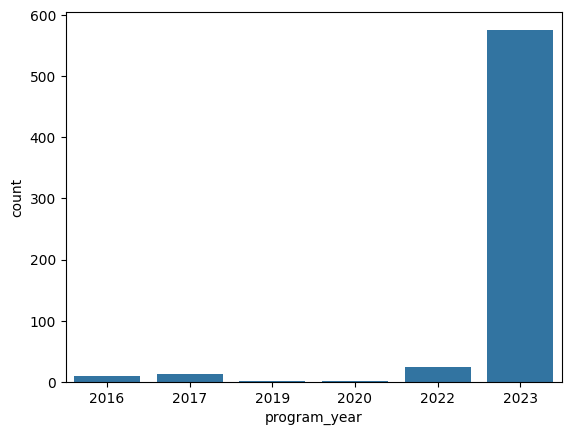

In [8]:
sns.barplot(df_workforce_boards_grouped["program_year"].value_counts().sort_index())

<Axes: xlabel='jurisdiction', ylabel='Count'>

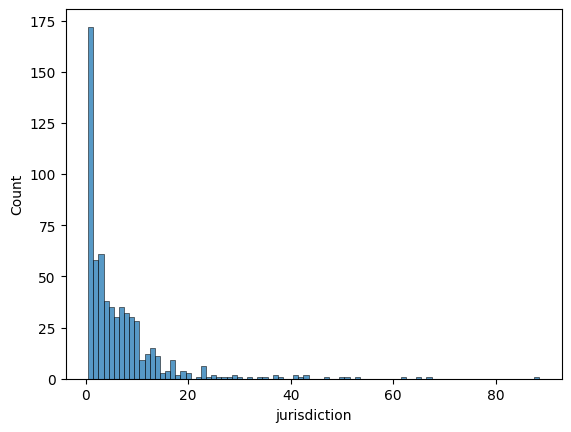

In [9]:
sns.histplot(df_workforce_boards_grouped["jurisdiction"].apply(len), discrete=True)

### Map Jurisdictions + States/Territories to Data Commons ID


In [10]:
df_workforce_boards_filtered = df_workforce_boards_grouped.explode("jurisdiction")
df_workforce_boards_filtered["jurisdiction_state"] = df_workforce_boards_filtered["jurisdiction"] + ", " + df_workforce_boards_filtered["state"]

In [11]:
place_names = df_workforce_boards_filtered["jurisdiction_state"].unique()
places = client.resolve.fetch_dcids_by_name(place_names).to_flat_dict()

In [12]:
# Extract just the DCIDs
dcids = {name: places[name] for name in place_names if isinstance(places[name], str)}

manual_dcids = {
    'St. Croix Island, Virgin Islands': "geoId/78010",
    'Austin City, Less Austin City Part In Williamson County, Texas': "geoId/4805000",
    'Balance Of Collin County Less Dallas City Part, Texas': "geoId/48085",
    'Balance Of Denton County Less Dallas City Part, Texas': "geoId/48121",
    'New Shoreham Town, Rhode Island': "geoId/4450500",
    'Lares Municipio, Puerto Rico': "geoId/72081",
    'Hormigueros Municipio, Puerto Rico': "geoId/72067",
    'Canovas Municipio, Puerto Rico': None,
    'Luquillo Municipio, Puerto Rico': "geoId/72089",
    'Toa Baja Municipio, Puerto Rico': "geoId/72137",
    'Bayamon Municipio, Puerto Rico': "geoId/72021",
    'Arroyo Municipio, Puerto Rico': "geoId/72015",
    'Balance Of Clackamas County Less Portland City, Oregon': "geoId/41005",
    'Franklin County (Including The City Of Columbus), Ohio': "geoId/39049",
    'Mahoning County Less Youngstown City, Ohio': "geoId/39099",
    'Summit County Including City Of Akron, Ohio': "geoId/39153",
    'Hempstead Town In Nassau County, New York': "geoId/3634000",
    'Hempstead Town, New York': "geoId/3634000",
    'Essex County Less Newark City, New Jersey': "geoId/34013",
    'Div. E & T Tradereadjustact, New Jersey': None,
    'Famis Stateside, New Jersey': None,
    'Nj Trenton Central Office, New Jersey': None,
    'Response Team, New Jersey': None,
    'Ui Statewide, New Jersey': None,
    'Workfirst Operations, New Jersey': None,
    'Carson City, Nevada': "geoId/3209700",
    'Balance Of St. Louis County Less Duluth City, Minnesota': "geoId/27137",
    'Balance Of Hennepin County Less Minneapolis City, Minnesota': "geoId/27053",
    'Upper Peninsula, Michigan': None,
    'Central Upper Peninsula, Michigan': None,
    'Dighton Town, Massachusetts': "geoId/2516950",
    'Hin25055Le Town, Massachusetts': None,
    'Windsor Town, Massachusetts': "geoId/2580685",
    'Wenham Town, Massachusetts': "wikidataId/Q2418343",
    'Carver Town, Massachusetts': "wikidataId/Q372315",
    'Shutesbury Town, Massachusetts': "geoId/2561905",
    'Balance Of Bossier Parish Less Shreveport City, Louisiana': "geoId/22015",
    'Balance Of Caddo Parish Less Shreveport City, Louisiana': "geoId/22015",
    'Terrebonne Consortium, Louisiana': "geoId/22109",
    'Kentucky Statewide, Kentucky': None,
    'Adair, Iowa': "geoId/19001",
    'Audubon, Iowa': "geoId/19009",
    'Cherokee, Iowa': "geoId/19035",
    'Fremont, Iowa': "geoId/19071",
    'Greene, Iowa': "geoId/19073",
    'Hamilton, Iowa': "geoId/19079",
    'Humboldt, Iowa': "geoId/19091",
    'Monona, Iowa': "geoId/19133",
    'Osceola, Iowa': "geoId/19143",
    'Plymouth, Iowa': "geoId/19149",
    'Pocahontas, Iowa': "geoId/19151",
    'Shelby, Iowa': "geoId/19165",
    'Union, Iowa': "geoId/19175",
    'Balance Of Du Page Co Less Chicago City, Illinois': "geoId/17043",
    'Balance Of Cook Co Less:, Illinois': "geoId/17031",
    'Hanover Township, Illinois': "geoId/1732694",
    'Maine Township, Illinois': "geoId/1746162",
    'Newtown Town, Connecticut': "geoId/0952980",
    'Contra Costa County Less Richmond City, California': "geoId/06013",
    'Alameda County Less Oakland City, California': "geoId/06001",
    'Lakewood City, California': "geoId/0639892",
    'Balance Of Pulaski County Less Little Rock City, Arkansas': "geoId/05119",
    'Camp Verde Reservation, Arizona': None,
    'Hualapai Reservation, Arizona': None,
    'Yavapai Reservation, Arizona': None,
    'Balance Of Gila County Less, Arizona': "geoId/04007",
    'Balance Of Pinal County Less, Arizona': "geoId/04021",
    'Maricopa Reservation, Arizona': None,
    'Maricopa Reservation In Pinal County, Arizona': None,
    'Papago Reservation, Arizona': None,
    'Payson Community Of Yavapai-Apache, Arizona': None,
    'Camp Verde Reservation In Yavapai County, Arizona': None,
    'Fort Mc Dowell Reservation In Maricopa County, Arizona': None,
    'Hualapai Reservation In Coconino County, Arizona': None,
    'Papago Reservation In Maricopa County, Arizona': None,
    'Pascua Yaqui Reservation, Arizona': None,
    'Pascua Yaqui Reservation In Pima County, Arizona': None,
    'Payson Community Of Yavapai-Apache In Gila County, Arizona': None,
    'Salt River Reservation, Arizona': None,
    'Salt River Reservation In Maricopa County, Arizona': None,
    'Yavapai Reservation In Yavapai County, Arizona': None,
    'Fort Mc Dowell Reservation, Arizona': None,
    'Rose Island, American Samoa': None,
    'Wade Hampton Borough, Alaska': None,
    'Anchorage/Mat-Su Economic Region, Alaska': "geoId/02020",
    'Gulf Coast Economic Region, Alaska': None,
    'Interior Economic Region, Alaska': None,
    'Northern Economic Region, Alaska': None,
    'Southeast Economic Region, Alaska': None,
    'Southwest Economic Region, Alaska': None,
    'Hudson County Less Jersey City, New Jersey': "geoId/34017",
    "District Of Coulumia, District Of Columbia": "geoId/11001",
    "Mobile City/Mobile County, Alabama": "geoId/01097",
    "Seattle-King County, Washington": "geoId/53033",
    "Queens County, New York": "geoId/36081"
}

places_dcids = dcids | manual_dcids

In [13]:
df_workforce_boards_filtered["dcid"] = df_workforce_boards_filtered["jurisdiction_state"].map(places_dcids)

In [14]:
entity_dcids = list(df_workforce_boards_filtered["dcid"].dropna().unique())

### Join with Land Area from Data Commons


In [15]:
land_areas = client.node.fetch_property_values(node_dcids=entity_dcids, properties="landArea").data

In [16]:
def get_landarea_dcid(arcs_obj):
    """
    Given an Arcs object like:
      Arcs(arcs={'landArea': NodeGroup(nodes=[Node(dcid='SquareMeter90056657', ...)])})
    return the dcid string, e.g. 'SquareMeter90056657'.
    """
    try:
        # Grab the first NodeGroup under 'landArea'
        nodes = arcs_obj.arcs.get("landArea").nodes
        if nodes:
            return nodes[0].dcid
    except Exception as e:
        print(f"Failed to parse dcid: {e}")
    return None

In [17]:
df_landareas =  { "dcid": [], "landarea_dcid": [] }

for place_dcid, value in land_areas.items():
    df_landareas["dcid"].append(place_dcid)
    df_landareas["landarea_dcid"].append(get_landarea_dcid(value))

df_landareas = pd.DataFrame(df_landareas)

Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to parse dcid: 'Properties' object has no attribute 'arcs'
Failed to 

In [18]:
df_landareas = pd.DataFrame(df_landareas)

In [19]:
def parse_landarea_dcid(s):
    if (type(s) != str):
        return None

    split_s = s.split("SquareMeter")
    if len(split_s) > 1:
        return int(split_s[1])
    
    return None

df_landareas["landarea"] = df_landareas["landarea_dcid"].apply(parse_landarea_dcid)

In [20]:
df_workforce_boards_filtered = df_workforce_boards_filtered.merge(df_landareas, on="dcid", how="left")

### Join with Population, Median Age, and Median Income from Data Commons


In [21]:
df_observations = client.observations_dataframe(entity_dcids=entity_dcids, variable_dcids=['Count_Person', 'Median_Age_Person', 'Median_Income_Person'], date='latest')

In [22]:
df_observations.to_csv("../data/processed/workforce_boards/data_commons_demographics.csv")

In [23]:
df_observations.groupby(by=["variable_name"])["entity"].nunique()

variable_name
Median Income of a Population    3781
Median age of population         3781
Total population                 3825
Name: entity, dtype: int64

In [24]:
# Because we can get multiple "latest" rows for a single entity, we will take the value which is the most recent date (year).
df_observations = df_observations.sort_values(by="date", ascending=False)

df_observations = df_observations.drop_duplicates(subset=["entity", "variable"])

In [25]:
df_observations_pivot = (
    df_observations
    .pivot_table(values=["value"], index=["entity"], columns=["variable"])
    .reset_index()
    .droplevel(level=0, axis=1)
    .rename(columns={
        "": "dcid",
        "Count_Person": "population",
        "Median_Age_Person": "median_age",
        "Median_Income_Person": "median_income"
    })
)

In [26]:
df_observations_pivot

variable,dcid,population,median_age,median_income
0,country/GUM,167777.0,NaN,NaN
1,country/MNP,44278.0,NaN,NaN
2,country/PLW,17695.0,NaN,NaN
3,geoId/01001,61464.0,39.2,36446.0
4,geoId/01003,261608.0,43.7,36552.0
...,...,...,...,...
3820,wikidataId/Q2418343,5284.0,NaN,NaN
3821,wikidataId/Q372315,11777.0,NaN,NaN
3822,wikidataId/Q5471700,1707.0,NaN,NaN
3823,wikidataId/Q5472435,2189.0,NaN,NaN


In [27]:
df_workforce_boards_filtered = df_workforce_boards_filtered.merge(df_observations_pivot, on="dcid", how="left")

### Calculate additional statistics


In [28]:
df_workforce_boards_filtered["population_per_sqm"] = df_workforce_boards_filtered["population"] / df_workforce_boards_filtered["landarea"]

### Perform manual quality checks


In [29]:
df_workforce_boards_filtered.sample(n=10)

,program_year,state,workforce_board_code,jurisdiction,jurisdiction_state,dcid,landarea_dcid,landarea,population,median_age,median_income,population_per_sqm
2190,2023,Massachusetts,25045,Chelmsford Town,"Chelmsford Town, Massachusetts",geoId/2501713135,SquareMeter57970150,5.797015e+07,36220.0,42.8,61858.0,0.000625
3892,2023,Alaska,2025,Fairbanks North Star Borough,"Fairbanks North Star Borough, Alaska",geoId/02090,SquareMeter18996838330,1.899684e+10,94951.0,32.4,44698.0,0.000005
708,2023,Tennessee,47165,Cumberland,"Cumberland, Tennessee",geoId/47035,SquareMeter1764575268,1.764575e+09,65618.0,53.0,30703.0,0.000037
3912,2023,Alaska,2035,Interior Economic Region,"Interior Economic Region, Alaska",None,NaN,NaN,NaN,NaN,NaN,NaN
1703,2023,Missouri,29030,Newton County,"Newton County, Missouri",geoId/29145,SquareMeter1618106506,1.618107e+09,61519.0,40.2,32935.0,0.000038
3548,2023,Connecticut,9090,West Haven City,"West Haven City, Connecticut",geoId/0982800,SquareMeter27842629,2.784263e+07,55379.0,36.0,38011.0,0.001989
3047,2023,Illinois,17095,De Witt County,"De Witt County, Illinois",geoId/17039,SquareMeter1029678323,1.029678e+09,15319.0,44.0,38106.0,0.000015
1548,2023,Nebraska,31015,Buffalo County,"Buffalo County, Nebraska",geoId/31019,SquareMeter2507679106,2.507679e+09,51156.0,34.6,36591.0,0.000020
2423,2023,Maryland,24040,Kent County,"Kent County, Maryland",geoId/24029,SquareMeter717394874,7.173949e+08,19557.0,48.4,40968.0,0.000027
1764,2023,Missouri,29080,Washington County,"Washington County, Missouri",geoId/29221,SquareMeter1968043965,1.968044e+09,23583.0,40.2,27934.0,0.000012


In [30]:
df_workforce_boards_filtered.to_csv("../data/processed/workforce_boards/wdb_all.csv")

In [31]:
df_workforce_boards_final = (
    df_workforce_boards_filtered
    .groupby(by=["program_year", "state", "workforce_board_code"])[["population_per_sqm", "median_age", "median_income", "jurisdiction"]]
    .agg({
        "population_per_sqm": "mean",
        "median_age": "mean",
        "median_income": "mean",
        "jurisdiction": list
    })
    .reset_index()
)

In [32]:
df_workforce_boards_final[df_workforce_boards_final.population_per_sqm.isna()]["workforce_board_code"].tolist()

[2035,
 60005,
 4080,
 4120,
 4125,
 4135,
 4145,
 4150,
 4155,
 66005,
 17040,
 21099,
 34120,
 69005,
 70005,
 78005]

In [33]:
df_workforce_boards_final = df_workforce_boards_final.dropna(subset=["population_per_sqm"])

In [34]:
df_workforce_boards_final["is_urban"] = df_workforce_boards_final["population_per_sqm"] > 0.00038610215

df_workforce_boards_final

,program_year,state,workforce_board_code,population_per_sqm,median_age,median_income,jurisdiction,is_urban
0,2016,Alabama,1005,0.000231,37.800000,35600.000000,[Jefferson County],False
1,2016,Alabama,1010,0.000130,38.400000,32499.000000,[Mobile City/Mobile County],False
2,2016,Alabama,1015,0.000033,41.330769,29150.692308,"[Autauga County, Baldwin County, Barbour Count...",False
3,2016,California,6085,0.000190,47.300000,65068.000000,[Marin County],False
4,2016,California,6230,0.000068,42.800000,47432.000000,[Napa County],False
...,...,...,...,...,...,...,...,...
621,2023,Wisconsin,55095,0.000044,45.350000,38516.000000,"[Brown County, Door County, Florence County, K...",False
622,2023,Wisconsin,55100,0.000019,48.188889,36931.333333,"[Adams County, Forest County, Langlade County,...",False
623,2023,Wisconsin,55105,0.000060,42.483333,42416.666667,"[Columbia County, Dane County, Dodge County, J...",False
624,2023,Wisconsin,55110,0.000028,41.850000,39401.500000,"[Grant County, Green County, Iowa County, Lafa...",False


In [35]:
sum(df_workforce_boards_final["is_urban"]) / len(df_workforce_boards_final["is_urban"])

0.21147540983606558

In [36]:
df_workforce_boards_final.to_csv("../data/processed/workforce_boards/wdb_demographics.csv")

In [37]:
df_workforce_boards_final

,program_year,state,workforce_board_code,population_per_sqm,median_age,median_income,jurisdiction,is_urban
0,2016,Alabama,1005,0.000231,37.800000,35600.000000,[Jefferson County],False
1,2016,Alabama,1010,0.000130,38.400000,32499.000000,[Mobile City/Mobile County],False
2,2016,Alabama,1015,0.000033,41.330769,29150.692308,"[Autauga County, Baldwin County, Barbour Count...",False
3,2016,California,6085,0.000190,47.300000,65068.000000,[Marin County],False
4,2016,California,6230,0.000068,42.800000,47432.000000,[Napa County],False
...,...,...,...,...,...,...,...,...
621,2023,Wisconsin,55095,0.000044,45.350000,38516.000000,"[Brown County, Door County, Florence County, K...",False
622,2023,Wisconsin,55100,0.000019,48.188889,36931.333333,"[Adams County, Forest County, Langlade County,...",False
623,2023,Wisconsin,55105,0.000060,42.483333,42416.666667,"[Columbia County, Dane County, Dodge County, J...",False
624,2023,Wisconsin,55110,0.000028,41.850000,39401.500000,"[Grant County, Green County, Iowa County, Lafa...",False


In [38]:
lf = pl.scan_parquet("../data/processed/wioa_data_filtered.parquet")

In [40]:
df = (
    lf.select(
        pl.col("exit_year"),
        pl.col("workforce_board_code_1")
    )
    .collect()
)

In [41]:
df_workforce_boards_final["workforce_board_code"] = df_workforce_boards_final["workforce_board_code"].astype(str)

In [42]:
workforce_board_codes = set(df_workforce_boards_final["workforce_board_code"].astype(str).unique())
workforce_board_codes_wioa = set(df["workforce_board_code_1"].unique())

In [43]:
# Overlapping Workforce Board Codes
len(workforce_board_codes & workforce_board_codes_wioa)

593

In [44]:
len(workforce_board_codes_wioa - workforce_board_codes)

139

In [45]:
df = df.to_pandas()

In [46]:
df_merge = df.merge(df_workforce_boards_final, left_on="workforce_board_code_1", right_on="workforce_board_code", how="left")

In [50]:
is_not_na = df_merge[~df_merge["program_year"].isna()]["workforce_board_code_1"].count()
is_na = df_merge[df_merge["program_year"].isna()]["workforce_board_code_1"].count()

is_not_na / (is_not_na + is_na)

np.float64(0.7992786120844562)

<Axes: xlabel='exit_year', ylabel='workforce_board_code_1'>

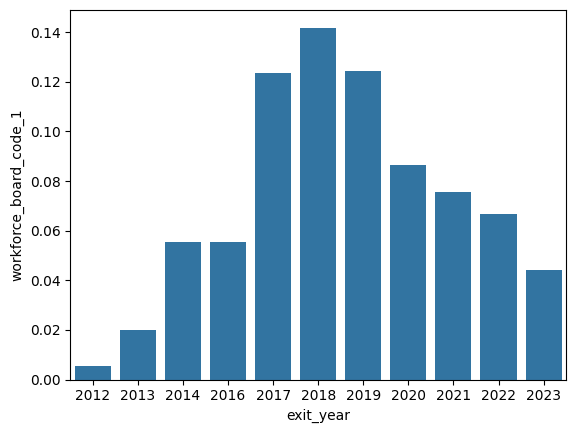

In [71]:
sns.barplot(df_merge[~df_merge["program_year"].isna()].groupby("exit_year")["workforce_board_code_1"].count() / 14486891)

<Axes: xlabel='exit_year', ylabel='workforce_board_code_1'>

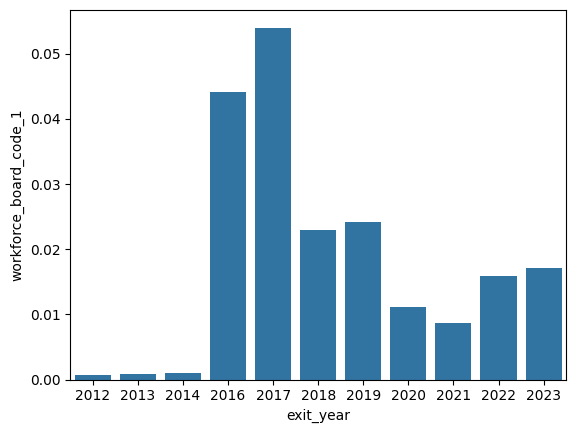

In [70]:
s = np.sum(df_merge[df_merge["program_year"].isna()].groupby("exit_year")["workforce_board_code_1"].count())

sns.barplot(df_merge[df_merge["program_year"].isna()].groupby("exit_year")["workforce_board_code_1"].count() / 14486891)

In [75]:
df_merge[df_merge["program_year"].isna()].groupby("exit_year")["workforce_board_code_1"].unique()

exit_year
2012    [22065, 28901, 41030, 6903, 12902, 22010, 4008...
2013    [12901, 22010, 12902, 22020, 22060, 22065, 690...
2014    [None, 40080, 22020, 25901, 26903, 12901, 2790...
2016    [26903, 18903, 29903, 46903, 6903, 12903, 9903...
2017    [37903, 26903, 41903, 18903, 35903, 9903, 5690...
                              ...                        
2019    [41903, 26903, 37999, 48080, 36903, 34990, 414...
2020    [26903, 41903, 55903, 48080, 4155, 27903, 3990...
2021    [41903, 36903, 26903, 6903, 4135, 39903, 4080,...
2022    [36903, 39903, 26903, 4135, 4150, 27903, 4155,...
2023    [36903, 35903, 26903, 39903, 12245, 41903, 349...
Name: workforce_board_code_1, Length: 11, dtype: object